---
date: "2026-05-10"
date-modified: last-modified
format:
  html:
    toc: true
---

# The Coupon Collector's Problem

## 1. Problem Statement

The **Coupon Collector's Problem** asks a classic question of expected value: Suppose there are $n$ distinct "coupons" (or toys in a cereal box, or baseball cards). If you collect one coupon at a time entirely at random (with replacement), **how many coupons on average do you need to draw before you have at least one of every kind?**

While the [Occupancy Problem](occupancy-problem.ipynb) asks for the *probability* of getting everything in a fixed number of trials, the Coupon Collector's Problem asks for the *expected time* (number of trials) it will take to guarantee the complete set. 

---

## 2. Mathematical Derivation (Using Linearity of Expectation)

Trying to calculate the exact probability distribution of the total time $T$ is complicated. However, calculating the *expected* time $E[T]$ becomes brilliantly simple if we break the total time down into smaller, independent phases and use the **Linearity of Expectation**.

**Step 1: Divide the Process into Phases**
Let $T$ be the total number of draws required to collect all $n$ distinct coupons. We can express $T$ as the sum of the times it takes to get each *new* coupon:
$$T = t_1 + t_2 + \dots + t_n$$
Here, $t_i$ represents the number of draws it takes to get the $i$-th new coupon *after* you have already collected exactly $i-1$ distinct coupons.

**Step 2: Define the Probability of Success for Each Phase**
When you are looking for your $i$-th new coupon, you already have $i-1$ distinct coupons in your hand. 
There are $n$ total coupons, meaning there are exactly $n - (i-1)$ "new" coupons still available. 
Therefore, on any given draw during this phase, the probability of drawing a new coupon is:
$$p_i = \frac{n - i + 1}{n}$$

**Step 3: The Expected Time for Each Phase**
Because each draw is independent, waiting for a success with a fixed probability $p_i$ perfectly models a **Geometric Distribution**. The expected value of a Geometric random variable is simply $1 / p$. 
Therefore, the expected number of draws to complete phase $i$ is:
$$E[t_i] = \frac{1}{p_i} = \frac{n}{n - i + 1}$$

**Step 4: The Final Expected Value**
By the Linearity of Expectation, the expected value of the total sum is the sum of the expected values, $E[T] = \sum E[t_i]$:
$$E[T] = E[t_1] + E[t_2] + \dots + E[t_n]$$
$$E[T] = \frac{n}{n} + \frac{n}{n-1} + \frac{n}{n-2} + \dots + \frac{n}{1}$$

Factoring out the $n$, we see this is simply $n$ multiplied by the Harmonic Harmonic series ($H_n$):
$$E[T] = n \sum_{k=1}^{n} \frac{1}{k} = n H_n$$

*(Note: Because the harmonic series $H_n$ is closely approximated by $\ln(n) + \gamma$, the expected time to collect $n$ coupons scales proportionally to $n \ln(n)$.)*

---

## 3. Classic Example Calculation

**Question:** If you roll a standard 6-sided die, how many rolls on average will it take before you have seen every single number (1 through 6) at least once?

**Solution:**
Here, the number of distinct coupons is $n = 6$. We apply the final formula:

$$E[T] = 6 \left( \frac{1}{1} + \frac{1}{2} + \frac{1}{3} + \frac{1}{4} + \frac{1}{5} + \frac{1}{6} \right)$$
$$E[T] = 6 \left( \frac{60}{60} + \frac{30}{60} + \frac{20}{60} + \frac{15}{60} + \frac{12}{60} + \frac{10}{60} \right)$$
$$E[T] = 6 \left( \frac{147}{60} \right) = \frac{147}{10} = 14.7$$

On average, you must roll the die **14.7 times** to ensure you have seen all 6 faces. Notice how much longer this is than the absolute minimum of 6 rolls—collecting those final, elusive numbers takes the vast majority of the time!

---

## 4. Python Simulation

We can empirically verify this expected value of 14.7 by simulating the die-rolling process thousands of times using `numpy`. We will also plot the distribution of the total time $T$ to show that it is highly right-skewed.



--- Simulation Results (10000 trials) ---
Empirical Average Rolls: 14.713
Theoretical Expectation: 14.700


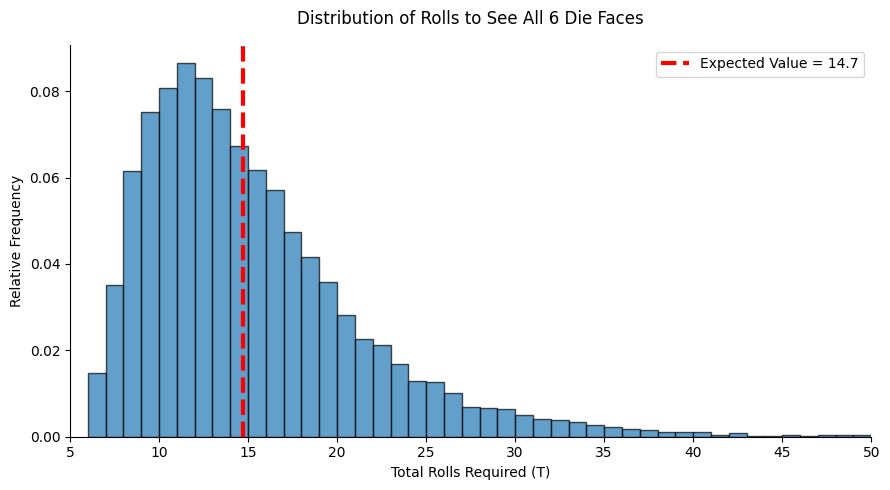

In [1]:
#| label: fig-coupon-collector
#| fig-cap: "Simulation of the Coupon Collector's Problem for a 6-sided die. The blue histogram shows the distribution of rolls required, with the red line indicating the mathematical expectation of 14.7."
#| echo: true

import numpy as np
import matplotlib.pyplot as plt

def simulate_coupon_collector(n):
    """Simulates one round of collecting n distinct coupons."""
    collected = set()
    draws = 0
    while len(collected) < n:
        draws += 1
        # Draw a random coupon from 1 to n
        coupon = np.random.randint(1, n + 1)
        collected.add(coupon)
    return draws

# Run the simulation 10,000 times for n = 6
n_coupons = 6
n_trials = 10000
results = [simulate_coupon_collector(n_coupons) for _ in range(n_trials)]

# Calculate empirical expected value
empirical_mean = np.mean(results)
theoretical_mean = 14.7

print(f"--- Simulation Results ({n_trials} trials) ---")
print(f"Empirical Average Rolls: {empirical_mean:.3f}")
print(f"Theoretical Expectation: {theoretical_mean:.3f}")

# Plotting the distribution
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(results, bins=range(min(results), max(results) + 2, 1), 
        color='#1f77b4', edgecolor='black', alpha=0.7, density=True)

# Add line for theoretical mean
ax.axvline(theoretical_mean, color='red', linestyle='dashed', linewidth=3, 
           label=f'Expected Value = {theoretical_mean}')

ax.set_title("Distribution of Rolls to See All 6 Die Faces", pad=15)
ax.set_xlabel("Total Rolls Required (T)")
ax.set_ylabel("Relative Frequency")
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(5, 50) # Most mass is here

plt.tight_layout()
plt.show()